In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/GGTC/chainB_pS136/'

In [5]:
# dataframe
df_phos = pd.read_csv('RMSF_data_avgchain.csv')
df = pd.read_csv('../unbiased_MD_analyses/RMSF_data_avgchain.csv')
dd = pd.DataFrame()
dd['Residue'] = df['Residue']
dd['Delta'] = df_phos['Isolated Avg.'] - df['Isolated Avg.']
dd['Error'] = np.sqrt(df_phos['Isolated Err.']**2 + df['Isolated Err.']**2)
dd.to_csv('deltaRMSF_phos_minus_wt.csv')
dd

,Residue,Delta,Error
0,15,-1.356333,0.785197
1,16,-0.713333,0.544945
2,17,0.654000,0.125674
3,18,0.686500,0.131211
4,19,0.609667,0.132478
...,...,...,...
163,178,7.508000,3.192638
164,179,8.019333,3.551052
165,180,8.729833,3.797641
166,181,9.831333,3.853863


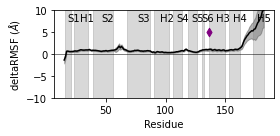

In [9]:
df = pd.read_csv('deltaRMSF_phos_minus_wt.csv')

ymax = 10

# secondary structure elements
# Beta strands based on DSSP:
beta_start = [16,23,39,68,90,106,119,130,136,153,173]
beta_end = [21,35,56,87,103,114,126,132,150,162,182]
beta_start = np.array(beta_start)
beta_end = np.array(beta_end)
strand_names = ["S1","H1","S2","S3","H2","S4","S5","S6","H3","H4","H5"]



plt.figure(figsize = (4,2))


plt.plot(df['Residue'],df['Delta'],color = 'black')
plt.fill_between(df['Residue'],df['Delta']-df['Error'],df['Delta']+df['Error'],color = 'black',alpha = 0.3)


plt.ylim(-ymax,ymax)
# secondary structure
for i in range(len(beta_start)):
    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
for i in range(len(beta_start)):
    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.75,strand_names[i],fontsize = 10)
    
plt.axhline(0,linewidth=0.5,color='black')
    
# buried PTM sites
#plt.scatter([286],[ymax*0.5],color = 'purple',marker='d')
#plt.scatter([340],[ymax*0.5],color = 'purple',marker='d')
plt.scatter([136],[ymax*0.5],color = 'purple',marker='d')
    
plt.xlabel('Residue')
plt.ylabel('deltaRMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('deltaRMSF_comparison.pdf')





